# Exercise 8 — Quasi-Newton Methods: BFGS

This notebook solves **Exercise Sheet 8: Quasi-Newton Methods** in a simple Python style.

The main method is **BFGS**.

BFGS is a Quasi-Newton method.

That means:

- Newton method uses the exact Hessian matrix.
- BFGS does not compute the exact Hessian every time.
- Instead, BFGS builds an approximation of the inverse Hessian.

This is useful because computing and solving with the Hessian can be expensive for large problems.

## 1. Import libraries

We keep the imports simple:

- `numpy` for vectors and matrices
- `matplotlib` for plots
- `scipy.sparse.diags` for the tridiagonal matrix

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

np.random.seed(0)

# 2. Idea of BFGS

For Newton's method, the search direction is

\[
d_k = -[\nabla^2 f(x_k)]^{-1}\nabla f(x_k)
\]

For BFGS, we use an approximation:

\[
d_k = -H_k \nabla f(x_k)
\]

Here:

\[
H_k \approx [\nabla^2 f(x_k)]^{-1}
\]

So \(H_k\) is an approximate inverse Hessian.

After every step, BFGS updates \(H_k\) using the change in position and gradient:

\[
s_k = x_{k+1}-x_k
\]

\[
y_k = \nabla f(x_{k+1})-\nabla f(x_k)
\]

The update is:

\[
H_k =
(I-\rho_k s_k y_k^T)H_{k-1}(I-\rho_k y_k s_k^T)
+\rho_k s_k s_k^T
\]

where

\[
\rho_k = \frac{1}{y_k^T s_k}
\]

# 3. Helper: tridiagonal matrix \(T_n\)

The exercise uses the matrix

\[
Q=T_n
\]

with

- `2` on the main diagonal
- `-1` on the upper diagonal
- `-1` on the lower diagonal

In [2]:
def create_tridiagonal_matrix(n, dense=False):
    """
    Create the tridiagonal matrix T_n.

    If dense=True, return a NumPy array.
    If dense=False, return a sparse matrix.
    """
    main = 2 * np.ones(n)
    off = -1 * np.ones(n - 1)

    Q_sparse = diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="csr"
    )

    if dense:
        return Q_sparse.toarray()

    return Q_sparse

In [3]:
Q_small = create_tridiagonal_matrix(5, dense=True)
print(Q_small)

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


# 4. Quadratic function

The quadratic function is

\[
f(x)=\frac12 x^TQx+p^Tx+c
\]

The gradient is

\[
\nabla f(x)=Qx+p
\]

The minimum satisfies

\[
Qx+p=0
\]

or

\[
Qx=-p
\]

In [4]:
def quadratic_factory(Q, p, c=0.0):
    """
    Create f and grad for a quadratic function.
    """

    def f(x):
        return 0.5 * x @ (Q @ x) + p @ x + c

    def grad(x):
        return Q @ x + p

    return f, grad

# 5. BFGS implementation

The function below implements BFGS.

I keep it readable and not too compact.

There are two step-size options:

1. `line_search="fixed"`  
   Use a fixed step size \(\alpha_k=1\) after the first step.

2. `line_search="exact_quadratic"`  
   For quadratic problems only, use

\[
\alpha_k =
-\frac{\nabla f(x_k)^T d_k}{d_k^T Q d_k}
\]

This exact line search is requested in Task 2(b).

In [5]:
def bfgs_method(
    f,
    grad,
    x0,
    alpha0=0.1,
    tol=1e-5,
    maxit=1000,
    line_search="fixed",
    Q_for_exact_line_search=None,
    fixed_alpha=1.0
):
    """
    Simple BFGS method.

    Parameters
    ----------
    f:
        Function value.
    grad:
        Gradient function.
    x0:
        Starting point.
    alpha0:
        First small step used to build the first inverse Hessian approximation.
    tol:
        Stop when the gradient norm is smaller than this.
    maxit:
        Maximum number of iterations.
    line_search:
        "fixed" or "exact_quadratic".
    Q_for_exact_line_search:
        Needed only for the quadratic exact line search.
    fixed_alpha:
        Step size used when line_search="fixed".

    Returns
    -------
    x:
        Final solution.
    residuals:
        Norm of the gradient over iterations.
    step_sizes:
        Step sizes used.
    function_values:
        Function values over iterations.
    """

    x_old = x0.copy().astype(float)
    g_old = grad(x_old)

    # First step from the algorithm
    x = x_old - alpha0 * g_old
    g = grad(x)

    s = x - x_old
    y = g - g_old

    n = len(x0)
    I = np.eye(n)

    # Initial inverse Hessian approximation
    yy = y @ y
    ys = y @ s

    if abs(yy) < 1e-30 or abs(ys) < 1e-30:
        H = I.copy()
    else:
        H = (ys / yy) * I

    residuals = [np.linalg.norm(g_old), np.linalg.norm(g)]
    step_sizes = [alpha0]
    function_values = [f(x_old), f(x)]

    for k in range(1, maxit + 1):
        res = np.linalg.norm(g)

        if res < tol:
            break

        # BFGS direction
        d = -H @ g

        # Choose step size
        if line_search == "exact_quadratic":
            Qd = Q_for_exact_line_search @ d
            denominator = d @ Qd

            if abs(denominator) < 1e-30:
                alpha = fixed_alpha
            else:
                alpha = -(g @ d) / denominator
        else:
            alpha = fixed_alpha

        # New point
        x_new = x + alpha * d
        g_new = grad(x_new)

        # Safety check
        if not np.all(np.isfinite(x_new)) or not np.all(np.isfinite(g_new)):
            print("Stopped because numbers became non-finite.")
            break

        s = x_new - x
        y = g_new - g

        ys = y @ s

        # If y^T s is not positive, the BFGS update is not safe.
        # Then we skip the update and keep the old H.
        if ys > 1e-14:
            rho = 1.0 / ys
            left = I - rho * np.outer(s, y)
            right = I - rho * np.outer(y, s)
            H = left @ H @ right + rho * np.outer(s, s)

        x = x_new
        g = g_new

        residuals.append(np.linalg.norm(g))
        step_sizes.append(alpha)
        function_values.append(f(x))

        # Another simple safety check for exploding functions
        if abs(function_values[-1]) > 1e100:
            print("Stopped because the function value became too large.")
            break

    return x, residuals, step_sizes, function_values

# 6. Conjugate Gradient method for comparison

For the quadratic problem, the exercise asks us to compare BFGS with CG.

CG is very good for symmetric positive definite quadratic problems.

In [6]:
def conjugate_gradient(Q, p, x0, tol=1e-5, maxit=2000):
    """
    Conjugate Gradient method for minimizing

        f(x) = 1/2 x^T Q x + p^T x

    The gradient is Qx + p.
    """

    x = x0.copy().astype(float)

    g = Q @ x + p
    d = -g

    res = np.linalg.norm(g)
    residuals = [res]

    for k in range(maxit):
        if res < tol:
            break

        Qd = Q @ d
        alpha = (res**2) / (d @ Qd)

        x = x + alpha * d
        g_new = g + alpha * Qd

        res_new = np.linalg.norm(g_new)
        residuals.append(res_new)

        beta = (res_new**2) / (res**2)

        d = -g_new + beta * d
        g = g_new
        res = res_new

    return x, residuals

# Task 2(a) — BFGS without line search on quadratic problem

We use:

\[
Q=T_{10}
\]

\[
p=\mathbf{1}
\]

\[
c=0
\]

\[
x_0=0
\]

First we test BFGS without line search, meaning \(\alpha_k=1\) after the first initialization step.

In [7]:
n = 10

Q = create_tridiagonal_matrix(n, dense=True)
p = np.ones(n)
x0 = np.zeros(n)

f_quad, grad_quad = quadratic_factory(Q, p)

x_bfgs_fixed, res_bfgs_fixed, alpha_bfgs_fixed, fvals_bfgs_fixed = bfgs_method(
    f_quad,
    grad_quad,
    x0,
    alpha0=0.1,
    tol=1e-8,
    maxit=200,
    line_search="fixed",
    fixed_alpha=1.0
)

x_cg, res_cg = conjugate_gradient(
    Q,
    p,
    x0,
    tol=1e-8,
    maxit=200
)

x_exact = np.linalg.solve(Q, -p)

print("BFGS without line search")
print("iterations:", len(res_bfgs_fixed) - 1)
print("final residual:", res_bfgs_fixed[-1])
print("error to exact solution:", np.linalg.norm(x_bfgs_fixed - x_exact))
print()

print("CG")
print("iterations:", len(res_cg) - 1)
print("final residual:", res_cg[-1])
print("error to exact solution:", np.linalg.norm(x_cg - x_exact))

BFGS without line search
iterations: 13
final residual: 3.678392300550806e-10
error to exact solution: 2.7158669278606257e-10

CG
iterations: 5
final residual: 5.019932605247481e-16
error to exact solution: 8.565282493038633e-15


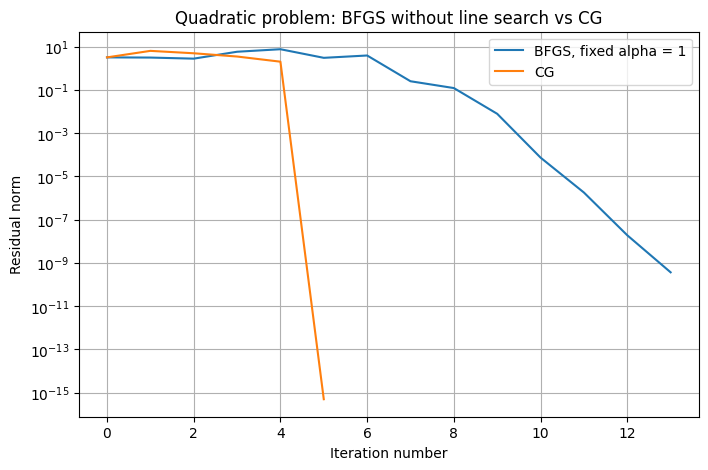

In [8]:
plt.figure(figsize=(8, 5))

plt.semilogy(res_bfgs_fixed, label="BFGS, fixed alpha = 1")
plt.semilogy(res_cg, label="CG")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Quadratic problem: BFGS without line search vs CG")
plt.legend()
plt.grid(True)
plt.show()

## Observation for Task 2(a)

CG is especially designed for quadratic problems.

BFGS also learns curvature information, but it needs a few updates to build a good inverse Hessian approximation.

So CG is usually the cleaner method for this exact quadratic problem.

# Task 2(b) — BFGS with exact line search

Now we use the exact line search for the quadratic problem:

\[
\alpha_k =
-\frac{\nabla f(x_k)^T d_k}{d_k^TQd_k}
\]

This step size is optimal along the BFGS direction for a quadratic function.

In [9]:
x_bfgs_exact, res_bfgs_exact, alpha_bfgs_exact, fvals_bfgs_exact = bfgs_method(
    f_quad,
    grad_quad,
    x0,
    alpha0=0.1,
    tol=1e-8,
    maxit=200,
    line_search="exact_quadratic",
    Q_for_exact_line_search=Q
)

print("BFGS with exact line search")
print("iterations:", len(res_bfgs_exact) - 1)
print("final residual:", res_bfgs_exact[-1])
print("error to exact solution:", np.linalg.norm(x_bfgs_exact - x_exact))
print()

print("CG")
print("iterations:", len(res_cg) - 1)
print("final residual:", res_cg[-1])
print("error to exact solution:", np.linalg.norm(x_cg - x_exact))

BFGS with exact line search
iterations: 6
final residual: 7.53644380168212e-15
error to exact solution: 7.215595591812694e-15

CG
iterations: 5
final residual: 5.019932605247481e-16
error to exact solution: 8.565282493038633e-15


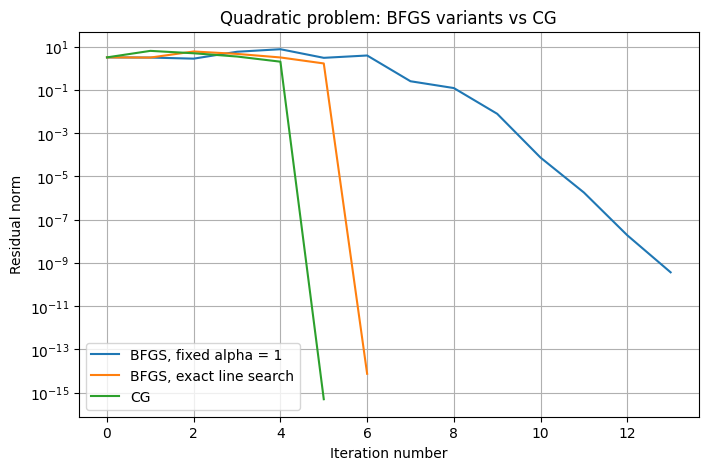

In [10]:
plt.figure(figsize=(8, 5))

plt.semilogy(res_bfgs_fixed, label="BFGS, fixed alpha = 1")
plt.semilogy(res_bfgs_exact, label="BFGS, exact line search")
plt.semilogy(res_cg, label="CG")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Quadratic problem: BFGS variants vs CG")
plt.legend()
plt.grid(True)
plt.show()

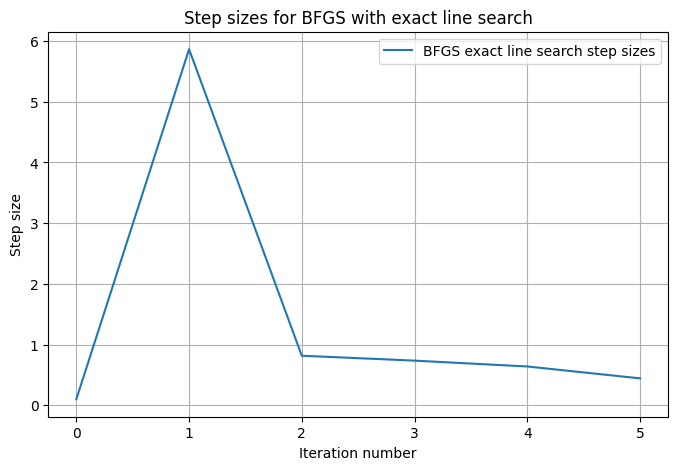

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(alpha_bfgs_exact, label="BFGS exact line search step sizes")
plt.xlabel("Iteration number")
plt.ylabel("Step size")
plt.title("Step sizes for BFGS with exact line search")
plt.legend()
plt.grid(True)
plt.show()

## Observation for Task 2(b)

The exact line search improves BFGS because every step is better chosen.

For a quadratic problem, CG is still a very natural reference method.

BFGS with exact line search can become very competitive because the curvature approximation improves with every step.

# 7. Himmelblau function

The Himmelblau function is

\[
f(x_1,x_2)=
(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2
\]

The exercise asks us to use:

\[
x_0=(20,0)^T
\]

We compare:

- BFGS without line search
- Newton method
- Malitsky-Mishchenko method

In [12]:
def himmelblau_f(x):
    x1 = x[0]
    x2 = x[1]

    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2


def himmelblau_grad(x):
    x1 = x[0]
    x2 = x[1]

    df_dx1 = 4*x1*(x1**2 + x2 - 11) + 2*(x1 + x2**2 - 7)
    df_dx2 = 2*(x1**2 + x2 - 11) + 4*x2*(x1 + x2**2 - 7)

    return np.array([df_dx1, df_dx2], dtype=float)


def himmelblau_hess(x):
    x1 = x[0]
    x2 = x[1]

    h11 = 12*x1**2 + 4*x2 - 42
    h12 = 4*x1 + 4*x2
    h22 = 12*x2**2 + 4*x1 - 26

    return np.array([
        [h11, h12],
        [h12, h22]
    ], dtype=float)

# 8. Simple Newton method

For the comparison, we implement a small Newton method.

This version uses `np.linalg.solve`.

For the 2D Himmelblau problem and the small \(f_3\) example, this is simple and readable.

In [13]:
def newton_method(f, grad, hess, x0, tol=1e-8, maxit=50):
    """
    Simple Newton method using a direct linear solver.
    """

    x = x0.copy().astype(float)
    residuals = []
    function_values = []

    for k in range(maxit):
        g = grad(x)
        res = np.linalg.norm(g)

        residuals.append(res)
        function_values.append(f(x))

        if res < tol:
            break

        H = hess(x)

        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            print("Newton stopped because Hessian was singular.")
            break

        x = x + d

        if not np.all(np.isfinite(x)):
            print("Newton stopped because numbers became non-finite.")
            break

    return x, residuals, function_values

# 9. Malitsky-Mishchenko method

This method is an adaptive gradient method.

It does not need the Hessian.

In [14]:
def malitsky_mishchenko_method(grad, x0, tol=1e-8, maxit=20000):
    """
    Simple Malitsky-Mishchenko adaptive gradient method.
    """

    alpha_old = 1e-16
    theta_old = 1e16

    x_old = x0.copy().astype(float)
    x = x_old - alpha_old * grad(x_old)

    residuals = [np.linalg.norm(grad(x))]
    step_sizes = [alpha_old]

    for k in range(1, maxit + 1):
        g = grad(x)
        g_old = grad(x_old)

        diff_x = np.linalg.norm(x - x_old)
        diff_g = np.linalg.norm(g - g_old)

        first_choice = np.sqrt(1 + theta_old) * alpha_old

        if diff_g == 0:
            second_choice = first_choice
        else:
            second_choice = diff_x / (2 * diff_g)

        alpha = min(first_choice, second_choice)

        if alpha <= 0 or not np.isfinite(alpha):
            alpha = 1e-6

        x_new = x - alpha * g
        res = np.linalg.norm(grad(x_new))

        residuals.append(res)
        step_sizes.append(alpha)

        if res < tol:
            x = x_new
            break

        theta_old = alpha / alpha_old
        alpha_old = alpha
        x_old = x
        x = x_new

        if not np.all(np.isfinite(x)):
            print("MM stopped because numbers became non-finite.")
            break

    return x, residuals, step_sizes

# Task 2(c) — Himmelblau comparison

Important practical note:

Starting at \((20,0)\), the gradient is very large.

So for the first BFGS initialization step, I use a small \(\alpha_0\).  
After that, the requested no-line-search setting \(\alpha_k=1\) is used.

In [15]:
x0_h = np.array([20.0, 0.0])

x_bfgs_h, res_bfgs_h, alpha_bfgs_h, fvals_bfgs_h = bfgs_method(
    himmelblau_f,
    himmelblau_grad,
    x0_h,
    alpha0=1e-4,
    tol=1e-8,
    maxit=500,
    line_search="fixed",
    fixed_alpha=1.0
)

x_newton_h, res_newton_h, fvals_newton_h = newton_method(
    himmelblau_f,
    himmelblau_grad,
    himmelblau_hess,
    x0_h,
    tol=1e-8,
    maxit=50
)

x_mm_h, res_mm_h, alpha_mm_h = malitsky_mishchenko_method(
    himmelblau_grad,
    x0_h,
    tol=1e-8,
    maxit=20000
)

print("BFGS")
print("result:", x_bfgs_h)
print("function value:", himmelblau_f(x_bfgs_h))
print("iterations:", len(res_bfgs_h) - 1)
print("final residual:", res_bfgs_h[-1])
print()

print("Newton")
print("result:", x_newton_h)
print("function value:", himmelblau_f(x_newton_h))
print("iterations:", len(res_newton_h) - 1)
print("final residual:", res_newton_h[-1])
print()

print("Malitsky-Mishchenko")
print("result:", x_mm_h)
print("function value:", himmelblau_f(x_mm_h))
print("iterations:", len(res_mm_h) - 1)
print("final residual:", res_mm_h[-1])

BFGS
result: [ 3.58442834 -1.84812653]
function value: 3.4449592365702024e-21
iterations: 25
final residual: 5.457586053534477e-10

Newton
result: [ 3.58442834 -1.84812653]
function value: 1.476747614573734e-26
iterations: 9
final residual: 1.5663904194712175e-12

Malitsky-Mishchenko
result: [ 3.58442834 -1.84812653]
function value: 8.238638529638767e-19
iterations: 56
final residual: 6.937143722067988e-09


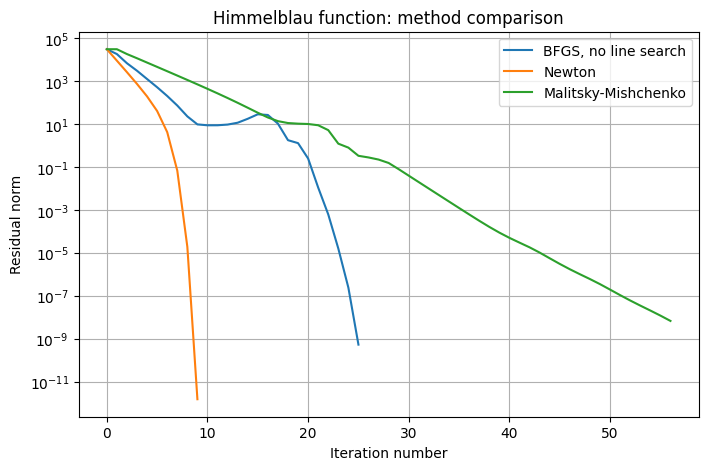

In [16]:
plt.figure(figsize=(8, 5))

plt.semilogy(res_bfgs_h, label="BFGS, no line search")
plt.semilogy(res_newton_h, label="Newton")
plt.semilogy(res_mm_h, label="Malitsky-Mishchenko")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Himmelblau function: method comparison")
plt.legend()
plt.grid(True)
plt.show()

## Observation for Himmelblau

Newton is usually very fast because it uses the exact Hessian.

BFGS is also fast after it has learned a useful inverse Hessian approximation.

Malitsky-Mishchenko is safer and only needs gradients, but it often needs many more iterations.

For a function like Himmelblau, the result can also depend on the starting point because the function has multiple minima.

# 10. Function \(f_3\)

We use

\[
f_3(x)=\sqrt{1+x^TQx}
\]

Its gradient is

\[
\nabla f_3(x)=\frac{Qx}{\sqrt{1+x^TQx}}
\]

The Hessian is

\[
\nabla^2 f_3(x)
=
\frac{Q}{\sqrt{1+x^TQx}}
-
\frac{(Qx)(Qx)^T}{(1+x^TQx)^{3/2}}
\]

The starting value is

\[
x_0=\lambda(1,1,\dots,1)^T
\]

with different values of \(\lambda\).

In [17]:
def f3_factory(Q):
    """
    Create f3, grad f3, and Hessian f3.
    """

    def f(x):
        return np.sqrt(1 + x @ (Q @ x))

    def grad(x):
        s = np.sqrt(1 + x @ (Q @ x))
        return (Q @ x) / s

    def hess(x):
        qx = Q @ x
        s = np.sqrt(1 + x @ qx)

        return Q / s - np.outer(qx, qx) / (s**3)

    return f, grad, hess

# Task 2(d) — BFGS on \(f_3\)

We compare:

- BFGS without line search
- Newton method
- Malitsky-Mishchenko method

For \(f_3\), the minimizer is near

\[
x=0
\]

But the Hessian of \(f_3\) becomes weak far away from the origin.

So Newton can sometimes take risky steps.

BFGS without line search can also be sensitive to the starting value.

In [18]:
n = 20
Q_f3 = create_tridiagonal_matrix(n, dense=True)

f3, grad3, hess3 = f3_factory(Q_f3)

lambda_values = [0.1, 0.5, 1.0, 1.5, 2.0]

results_f3 = {}

for lam in lambda_values:
    x0 = lam * np.ones(n)

    x_bfgs_3, res_bfgs_3, alpha_bfgs_3, fvals_bfgs_3 = bfgs_method(
        f3,
        grad3,
        x0,
        alpha0=0.1,
        tol=1e-8,
        maxit=500,
        line_search="fixed",
        fixed_alpha=1.0
    )

    x_newton_3, res_newton_3, fvals_newton_3 = newton_method(
        f3,
        grad3,
        hess3,
        x0,
        tol=1e-8,
        maxit=50
    )

    x_mm_3, res_mm_3, alpha_mm_3 = malitsky_mishchenko_method(
        grad3,
        x0,
        tol=1e-8,
        maxit=20000
    )

    results_f3[lam] = {
        "BFGS residuals": res_bfgs_3,
        "Newton residuals": res_newton_3,
        "MM residuals": res_mm_3,
        "BFGS iterations": len(res_bfgs_3) - 1,
        "Newton iterations": len(res_newton_3) - 1,
        "MM iterations": len(res_mm_3) - 1,
        "BFGS final residual": res_bfgs_3[-1],
        "Newton final residual": res_newton_3[-1],
        "MM final residual": res_mm_3[-1],
        "BFGS norm x": np.linalg.norm(x_bfgs_3),
        "Newton norm x": np.linalg.norm(x_newton_3),
        "MM norm x": np.linalg.norm(x_mm_3)
    }

for lam in lambda_values:
    row = results_f3[lam]

    print("lambda =", lam)
    print("BFGS iterations:", row["BFGS iterations"], "final residual:", row["BFGS final residual"], "||x||:", row["BFGS norm x"])
    print("Newton iterations:", row["Newton iterations"], "final residual:", row["Newton final residual"], "||x||:", row["Newton norm x"])
    print("MM iterations:", row["MM iterations"], "final residual:", row["MM final residual"], "||x||:", row["MM norm x"])
    print("-" * 80)

/tmp/ipykernel_4920/3488581169.py:17: RuntimeWarning: overflow encountered in scalar power
  return Q / s - np.outer(qx, qx) / (s**3)


Newton stopped because Hessian was singular.


lambda = 0.1
BFGS iterations: 25 final residual: 5.010960320960471e-09 ||x||: 3.770508239644799e-09
Newton iterations: 3 final residual: 1.6209363407021978e-23 ||x||: 1.2455043920374518e-22
MM iterations: 774 final residual: 9.742822961953202e-09 ||x||: 4.2408416371859e-07
--------------------------------------------------------------------------------
lambda = 0.5
BFGS iterations: 24 final residual: 2.3672000165204035e-09 ||x||: 1.0053948373875802e-09
Newton iterations: 4 final residual: 6.431098614937922e-13 ||x||: 2.0336919419749198e-12
MM iterations: 885 final residual: 9.943431696896932e-09 ||x||: 4.329812944085033e-07
--------------------------------------------------------------------------------
lambda = 1.0
BFGS iterations: 22 final residual: 3.291625158974071e-09 ||x||: 2.0563368716530475e-09
Newton iterations: 49 final residual: 0.6147051290214138 ||x||: 1.7470209215036202e+111
MM iterations: 896 final residual: 9.713138118899477e-09 ||x||: 4.229675262069902e-07
------------

## Plot \(f_3\) comparison for selected \(\lambda\)

We plot only a few selected cases so the notebook stays readable.

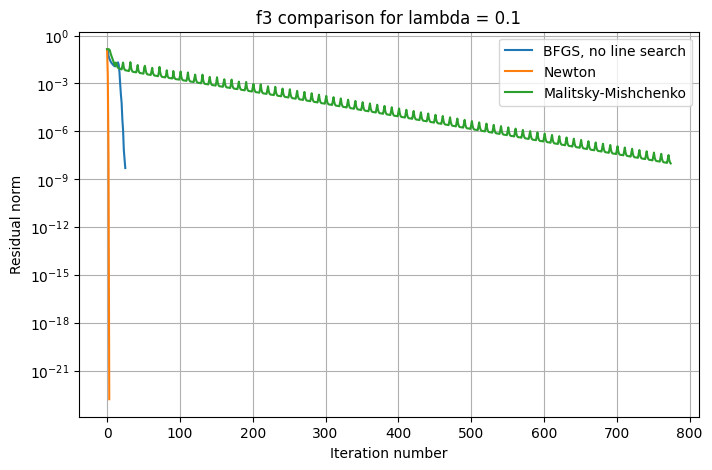

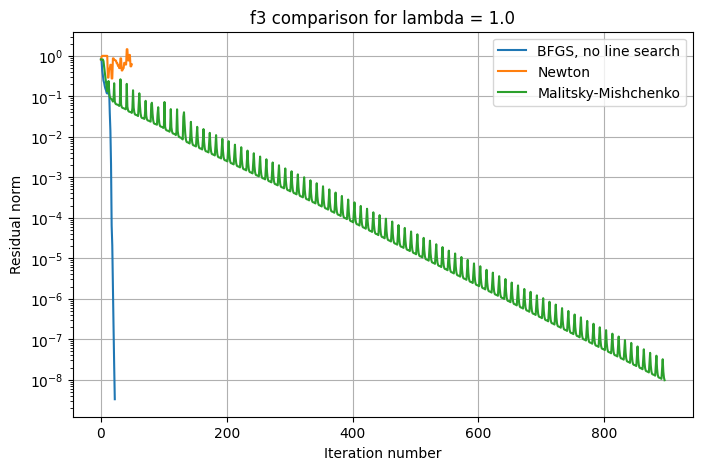

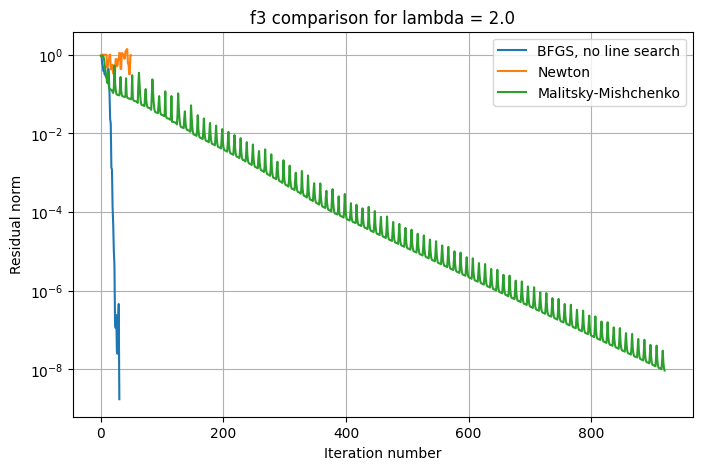

In [19]:
for lam in [0.1, 1.0, 2.0]:
    row = results_f3[lam]

    plt.figure(figsize=(8, 5))

    plt.semilogy(row["BFGS residuals"], label="BFGS, no line search")
    plt.semilogy(row["Newton residuals"], label="Newton")
    plt.semilogy(row["MM residuals"], label="Malitsky-Mishchenko")

    plt.xlabel("Iteration number")
    plt.ylabel("Residual norm")
    plt.title(f"f3 comparison for lambda = {lam}")
    plt.legend()
    plt.grid(True)
    plt.show()

## Observation for \(f_3\)

For small starting values, Newton and BFGS can work well.

For larger starting values, plain Newton and BFGS without line search can become less reliable.

Why?

Because \(f_3\) does not have strong curvature far away from the origin.

So:

- Newton may take steps that are too aggressive.
- BFGS may build a poor Hessian approximation if the early steps are not good.
- Malitsky-Mishchenko is slower but usually more stable because it adapts the step size.

This is why line search or damping is often important in practical Quasi-Newton methods.

# Final summary

## What BFGS does

BFGS avoids computing the exact Hessian.

Instead of solving

\[
\nabla^2 f(x_k)d_k=-\nabla f(x_k)
\]

it uses

\[
d_k=-H_k\nabla f(x_k)
\]

where \(H_k\) is an approximation of the inverse Hessian.

## Memory and cost

BFGS stores a full \(n \times n\) matrix \(H_k\).

So the memory cost is

\[
O(n^2)
\]

This is more than gradient methods, but less expensive than repeatedly computing and factorizing exact Hessians.

## Main observations

### Quadratic problem

CG is very natural and efficient.

BFGS improves when exact line search is used.

### Himmelblau function

Newton is very fast.  
BFGS also performs well if the first step is chosen carefully.  
Malitsky-Mishchenko is more robust but slower.

### \(f_3\)

Without line search, BFGS can be sensitive.

For difficult starting values, damping or line search is useful.

## Simple practical advice

- Use CG for large symmetric positive definite quadratic problems.
- Use Newton when exact Hessians are affordable and reliable.
- Use BFGS when Hessians are expensive but curvature information is still useful.
- Use line search or damping when the starting point is far from the minimizer.